# IndoBERT Sentiment Fine-Tuning Run 3 \u2014 Weighted Loss with Lower Learning Rate


## Research Context
Run 1 baseline had better accuracy but weak Neutral recall. Run 1 results: accuracy `0.7416143987`, macro F1 `0.6926732992`, weighted F1 `0.7364500012`, Neutral precision `0.5638247763`, Neutral recall `0.4525519849`, and Neutral F1 `0.5020973154`.

Run 2 weighted loss improved macro F1, weighted F1, Neutral recall, and Neutral F1, but reduced accuracy and Neutral precision. Run 2 results: accuracy `0.7328197437`, macro F1 `0.7033754261`, weighted F1 `0.7403101705`, Neutral precision `0.4723702665`, Neutral recall `0.6366729679`, and Neutral F1 `0.5423510467`.

Run 3 keeps weighted cross entropy loss and lowers the learning rate from `2e-5` to `1e-5`. The goal is to test whether a lower learning rate improves stability and the trade-off between Neutral recall, Neutral precision, macro F1, and overall accuracy.

## Experiment Setup
Run 3 writes to a separate Google Drive folder and must not overwrite Run 1 or Run 2 outputs.

In [5]:
RUN_NAME = "run_3_weighted_loss_lr_1e-5"
BASELINE_RUN_NAME = "run_1_baseline"
RUN_2_NAME = "run_2_weighted_loss"


## Environment Setup
Run this notebook in Google Colab with GPU runtime enabled. Package installation is intended for Colab only.

In [6]:
!pip -q install torch transformers datasets evaluate accelerate safetensors huggingface_hub scikit-learn pandas matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 9.0 MB/s eta 0:00:00


## GPU Check
Check CUDA availability and print the GPU name.

In [7]:
import torch

print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))
else:
    raise RuntimeError("GPU runtime is required for Run 3 IndoBERT fine-tuning.")


CUDA available: True
GPU: Tesla T4


## Google Drive Mount
The base path is configured once through `DRIVE_PROJECT_DIR`. Run 3 outputs use separate `saved_model`, `checkpoints`, and `figures` directories.

In [8]:
from google.colab import drive
from pathlib import Path

drive.mount("/content/drive")

DRIVE_PROJECT_DIR = Path("/content/drive/MyDrive/SentiRank")
DATASET_DIR = DRIVE_PROJECT_DIR / "datasets" / "processed" / "indobert"
OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_NAME
FIGURE_DIR = OUTPUT_DIR / "figures"
CHECKPOINT_DIR = OUTPUT_DIR / "checkpoints"
MODEL_OUTPUT_DIR = DRIVE_PROJECT_DIR / "ml-service" / "saved_models" / "indobert" / RUN_NAME
BASELINE_OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs" / "indobert" / BASELINE_RUN_NAME
RUN_2_OUTPUT_DIR = DRIVE_PROJECT_DIR / "outputs" / "indobert" / RUN_2_NAME

for output_path in [OUTPUT_DIR, FIGURE_DIR, CHECKPOINT_DIR, MODEL_OUTPUT_DIR]:
    output_path.mkdir(parents=True, exist_ok=True)

print("Run 3 output:", OUTPUT_DIR)
print("Run 3 artifact:", MODEL_OUTPUT_DIR)
print("Run 1 baseline:", BASELINE_OUTPUT_DIR)
print("Run 2 weighted loss:", RUN_2_OUTPUT_DIR)


Mounted at /content/drive
Run 3 output: /content/drive/MyDrive/SentiRank/outputs/indobert/run_3_weighted_loss_lr_1e-5
Run 3 artifact: /content/drive/MyDrive/SentiRank/ml-service/saved_models/indobert/run_3_weighted_loss_lr_1e-5
Run 1 baseline: /content/drive/MyDrive/SentiRank/outputs/indobert/run_1_baseline
Run 2 weighted loss: /content/drive/MyDrive/SentiRank/outputs/indobert/run_2_weighted_loss


## Dataset Paths
Expected input files in `DATASET_DIR`:
- `train.csv`
- `validation.csv`
- `test.csv`
- `label_mapping.json`

In [9]:
TRAIN_FILE = DATASET_DIR / "train.csv"
VALIDATION_FILE = DATASET_DIR / "validation.csv"
TEST_FILE = DATASET_DIR / "test.csv"
LABEL_MAPPING_FILE = DATASET_DIR / "label_mapping.json"

for file_path in [TRAIN_FILE, VALIDATION_FILE, TEST_FILE, LABEL_MAPPING_FILE]:
    if not file_path.is_file():
        raise FileNotFoundError(f"Missing required input file: {file_path}")


## Dataset Loading and Validation
Required columns are `text_indobert`, `label_id`, and `final_sentiment`. Print dataset sizes and label distributions for train, validation, and test splits.

In [10]:
import json
import random

import numpy as np
import pandas as pd

REQUIRED_COLUMNS = {"text_indobert", "label_id", "final_sentiment"}
EXPECTED_LABELS = {"Negative", "Neutral", "Positive"}
EXPECTED_LABEL_IDS = {0, 1, 2}

def load_split(path: Path, split_name: str) -> pd.DataFrame:
    data = pd.read_csv(path)
    missing_columns = REQUIRED_COLUMNS - set(data.columns)
    if missing_columns:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing_columns)}")
    empty_text_count = data["text_indobert"].fillna("").astype(str).str.strip().eq("").sum()
    if empty_text_count:
        raise ValueError(f"{split_name} contains {empty_text_count} empty text rows")
    return data

train_df = load_split(TRAIN_FILE, "train")
validation_df = load_split(VALIDATION_FILE, "validation")
test_df = load_split(TEST_FILE, "test")
label_mapping = {label: int(label_id) for label, label_id in json.loads(LABEL_MAPPING_FILE.read_text(encoding="utf-8")).items()}

if set(label_mapping.keys()) != EXPECTED_LABELS:
    raise ValueError(f"Unexpected label names: {label_mapping}")
if set(label_mapping.values()) != EXPECTED_LABEL_IDS:
    raise ValueError(f"Unexpected label IDs: {label_mapping}")

id2label = {label_id: label for label, label_id in label_mapping.items()}
label2id = label_mapping

print("Dataset sizes:")
print({"train": len(train_df), "validation": len(validation_df), "test": len(test_df)})

for split_name, data in {"train": train_df, "validation": validation_df, "test": test_df}.items():
    print(f"\n{split_name} label distribution")
    print(data["label_id"].map(id2label).value_counts().sort_index())


Dataset sizes:
{'train': 68446, 'validation': 14668, 'test': 14668}

train label distribution
label_id
Negative    27780
Neutral     12340
Positive    28326
Name: count, dtype: int64

validation label distribution
label_id
Negative    5953
Neutral     2644
Positive    6071
Name: count, dtype: int64

test label distribution
label_id
Negative    5953
Neutral     2645
Positive    6070
Name: count, dtype: int64


## Class Weight Calculation
Calculate class weights from the train split with `compute_class_weight(class_weight="balanced")`. Expected train distribution is Negative `27780`, Neutral `12340`, Positive `28326`. Save weights to `indobert_class_weights.json`.

In [11]:
from sklearn.utils.class_weight import compute_class_weight

classes = np.array([0, 1, 2])
train_labels = train_df["label_id"].astype(int).to_numpy()
weights = compute_class_weight(class_weight="balanced", classes=classes, y=train_labels)
class_weights_tensor = torch.tensor(weights, dtype=torch.float)
class_weights_payload = {
    "run_name": RUN_NAME,
    "method": "sklearn.utils.class_weight.compute_class_weight(class_weight='balanced')",
    "train_distribution": train_df["label_id"].map(id2label).value_counts().sort_index().to_dict(),
    "weights_by_label": {id2label[int(label_id)]: float(weight) for label_id, weight in zip(classes, weights)},
    "weights_by_id": {str(int(label_id)): float(weight) for label_id, weight in zip(classes, weights)},
}

(OUTPUT_DIR / "indobert_class_weights.json").write_text(
    json.dumps(class_weights_payload, indent=2, sort_keys=True), encoding="utf-8"
)
class_weights_payload


{'run_name': 'run_3_weighted_loss_lr_1e-5',
 'method': "sklearn.utils.class_weight.compute_class_weight(class_weight='balanced')",
 'train_distribution': {'Negative': 27780,
  'Neutral': 12340,
  'Positive': 28326},
 'weights_by_label': {'Negative': 0.8212862970962324,
  'Neutral': 1.848892490545651,
  'Positive': 0.8054555296665019},
 'weights_by_id': {'0': 0.8212862970962324,
  '1': 1.848892490545651,
  '2': 0.8054555296665019}}

## Tokenization
Use `indobenchmark/indobert-base-p1`, `max_length = 128`, and `AutoTokenizer` to tokenize `text_indobert`.

In [12]:
from datasets import Dataset
from transformers import AutoTokenizer, DataCollatorWithPadding

MODEL_NAME = "indobenchmark/indobert-base-p1"
MAX_LENGTH = 128

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def to_hf_dataset(data: pd.DataFrame) -> Dataset:
    return Dataset.from_pandas(
        data[["text_indobert", "label_id"]].rename(columns={"label_id": "labels"}),
        preserve_index=False,
    )

def tokenize_batch(batch):
    return tokenizer(batch["text_indobert"], truncation=True, max_length=MAX_LENGTH)

train_dataset = to_hf_dataset(train_df).map(tokenize_batch, batched=True)
validation_dataset = to_hf_dataset(validation_df).map(tokenize_batch, batched=True)
test_dataset = to_hf_dataset(test_df).map(tokenize_batch, batched=True)
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)


config.json:   0%|          | 0.00/1.53k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/229k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Map:   0%|          | 0/68446 [00:00<?, ? examples/s]

Map:   0%|          | 0/14668 [00:00<?, ? examples/s]

Map:   0%|          | 0/14668 [00:00<?, ? examples/s]

## Model Setup
Use `AutoModelForSequenceClassification` with `num_labels = 3`, `id2label`, and `label2id`.

In [13]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label=id2label,
    label2id=label2id,
)


[transformers] You passed `num_labels=3` which is incompatible to the `id2label` map of length `5`.


pytorch_model.bin:   0%|          | 0.00/498M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.weight | MISSING | 
classifier.bias   | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


## Custom Weighted Trainer
Override `compute_loss`, use weighted cross entropy, move class weights to the logits device, and preserve compatibility with Hugging Face Trainer kwargs.

In [14]:
from transformers import Trainer

class WeightedTrainer(Trainer):
    def __init__(self, *args, class_weights_tensor: torch.Tensor, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights_tensor = class_weights_tensor

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels", None)
        if labels is None:
            raise ValueError("WeightedTrainer requires labels in inputs.")
        outputs = model(**inputs)
        logits = outputs["logits"] if isinstance(outputs, dict) else outputs.logits
        loss_function = torch.nn.CrossEntropyLoss(
            weight=self.class_weights_tensor.to(logits.device)
        )
        loss = loss_function(
            logits.view(-1, model.config.num_labels),
            labels.view(-1),
        )
        return (loss, outputs) if return_outputs else loss


model.safetensors:   0%|          | 0.00/498M [00:00<?, ?B/s]

## Training Configuration
Run 3 config: model `indobenchmark/indobert-base-p1`, loss `weighted_cross_entropy`, max length `128`, batch size `16`, learning rate `1e-5`, epochs `3`, random state `42`, epoch evaluation/save, best model by `f1_macro`, `load_best_model_at_end = True`, and `save_total_limit = 2`. If GPU memory is limited, use batch size `8` with `gradient_accumulation_steps = 2`.

In [15]:
import inspect

from transformers import EarlyStoppingCallback, TrainingArguments

BATCH_SIZE = 16
GRADIENT_ACCUMULATION_STEPS = 1
LEARNING_RATE = 1e-5
EPOCHS = 3
RANDOM_STATE = 42

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

training_argument_names = set(inspect.signature(TrainingArguments.__init__).parameters.keys())
strategy_key = "eval_strategy" if "eval_strategy" in training_argument_names else "evaluation_strategy"
training_kwargs = {
    "output_dir": str(CHECKPOINT_DIR),
    strategy_key: "epoch",
    "save_strategy": "epoch",
    "learning_rate": LEARNING_RATE,
    "per_device_train_batch_size": BATCH_SIZE,
    "per_device_eval_batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "num_train_epochs": EPOCHS,
    "weight_decay": 0.01,
    "load_best_model_at_end": True,
    "metric_for_best_model": "f1_macro",
    "greater_is_better": True,
    "report_to": [],
    "seed": RANDOM_STATE,
}
if "logging_strategy" in training_argument_names:
    training_kwargs["logging_strategy"] = "epoch"
if "save_total_limit" in training_argument_names:
    training_kwargs["save_total_limit"] = 2

training_args = TrainingArguments(**training_kwargs)


## Metrics Function
Compute accuracy, macro precision, macro recall, macro F1, weighted precision, weighted recall, and weighted F1.

In [16]:
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

def compute_metrics(eval_prediction):
    logits, labels = eval_prediction
    predictions = np.argmax(logits, axis=-1)
    precision_macro, recall_macro, f1_macro, _ = precision_recall_fscore_support(
        labels, predictions, average="macro", zero_division=0
    )
    precision_weighted, recall_weighted, f1_weighted, _ = precision_recall_fscore_support(
        labels, predictions, average="weighted", zero_division=0
    )
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "precision_macro": float(precision_macro),
        "recall_macro": float(recall_macro),
        "f1_macro": float(f1_macro),
        "precision_weighted": float(precision_weighted),
        "recall_weighted": float(recall_weighted),
        "f1_weighted": float(f1_weighted),
    }


## Training
Use `WeightedTrainer`, save the best model, and print the best checkpoint, best metric, and final training runtime.

In [17]:
trainer_argument_names = set(inspect.signature(Trainer.__init__).parameters.keys())
trainer_tokenizer_kwargs = (
    {"processing_class": tokenizer}
    if "processing_class" in trainer_argument_names
    else {"tokenizer": tokenizer}
)

model.config.id2label = id2label
model.config.label2id = label2id

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=validation_dataset,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
    class_weights_tensor=class_weights_tensor,
    **trainer_tokenizer_kwargs,
)

train_result = trainer.train()
trainer.model.config.id2label = id2label
trainer.model.config.label2id = label2id
trainer.save_model(str(MODEL_OUTPUT_DIR))
tokenizer.save_pretrained(str(MODEL_OUTPUT_DIR))

print("Best checkpoint:", trainer.state.best_model_checkpoint)
print("Best metric:", trainer.state.best_metric)
print("Final training runtime:", train_result.metrics.get("train_runtime"))


Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
1,0.663784,0.601781,0.744205,0.721553,0.739861,0.720495,0.777528,0.744205,0.754005
2,0.553145,0.601903,0.763499,0.731309,0.745744,0.735056,0.779049,0.763499,0.769031
3,0.487165,0.628912,0.763158,0.731449,0.746454,0.734905,0.780332,0.763158,0.769102


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Best checkpoint: /content/drive/MyDrive/SentiRank/outputs/indobert/run_3_weighted_loss_lr_1e-5/checkpoints/checkpoint-8556
Best metric: 0.735055992971196
Final training runtime: 2436.1101


## Save Training History
Save trainer log history to `indobert_training_history.csv` and `indobert_training_history.json`.

In [18]:
history_df = pd.DataFrame(trainer.state.log_history)
preferred_history_columns = [
    "epoch",
    "loss",
    "eval_loss",
    "eval_accuracy",
    "eval_precision_macro",
    "eval_recall_macro",
    "eval_f1_macro",
    "eval_f1_weighted",
    "learning_rate",
    "grad_norm",
    "step",
]
ordered_history_columns = [column for column in preferred_history_columns if column in history_df.columns]
remaining_history_columns = [column for column in history_df.columns if column not in ordered_history_columns]
history_df = history_df[ordered_history_columns + remaining_history_columns]
history_df.to_csv(OUTPUT_DIR / "indobert_training_history.csv", index=False)
(OUTPUT_DIR / "indobert_training_history.json").write_text(
    history_df.to_json(orient="records", indent=2), encoding="utf-8"
)
history_df.tail()


,epoch,loss,eval_loss,eval_accuracy,eval_precision_macro,eval_recall_macro,eval_f1_macro,eval_f1_weighted,learning_rate,grad_norm,...,eval_precision_weighted,eval_recall_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
2,2.0,0.553145,NaN,NaN,NaN,NaN,NaN,NaN,3.334113e-06,4.688096,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2.0,NaN,0.601903,0.763499,0.731309,0.745744,0.735056,0.769031,NaN,NaN,...,0.779049,0.763499,53.3036,275.178,17.203,NaN,NaN,NaN,NaN,NaN
4,3.0,0.487165,NaN,NaN,NaN,NaN,NaN,NaN,7.791803e-10,4.038445,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,3.0,NaN,0.628912,0.763158,0.731449,0.746454,0.734905,0.769102,NaN,NaN,...,0.780332,0.763158,53.6767,273.266,17.084,NaN,NaN,NaN,NaN,NaN
6,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,2436.1101,84.289,5.268,5.981319e+15,0.568031


## Test Evaluation
Evaluate the best model on the test set and save metrics, classification report, and confusion matrix.

In [19]:
from datetime import datetime, timezone
from sklearn.metrics import classification_report, confusion_matrix

test_metrics = trainer.evaluate(test_dataset, metric_key_prefix="test")
prediction_output = trainer.predict(test_dataset)
test_logits = prediction_output.predictions
test_probabilities = torch.nn.functional.softmax(torch.tensor(test_logits), dim=-1).numpy()
test_predictions = np.argmax(test_probabilities, axis=-1)
test_labels = prediction_output.label_ids

classification_report_dict = classification_report(
    test_labels,
    test_predictions,
    labels=[0, 1, 2],
    target_names=[id2label[0], id2label[1], id2label[2]],
    output_dict=True,
    zero_division=0,
)
confusion_matrix_data = confusion_matrix(test_labels, test_predictions, labels=[0, 1, 2])

QUALITY_FILTER_RULES = [
    "morse_like_text",
    "high_symbol_ratio",
    "high_digit_ratio",
    "too_few_alphabet_chars",
    "too_short_after_cleaning",
    "repeated_garbage_pattern",
]
PREPROCESSING_VERSION = "preprocess_indobert_quality_filtering_v1"

preprocessing_config = {
    "pipeline_name": "preprocess_indobert.py",
    "preprocessing_version": PREPROCESSING_VERSION,
    "text_quality_filtering_enabled": True,
    "filtering_rules": QUALITY_FILTER_RULES,
    "input_dataset_path": "datasets/processed/reviews_final.csv",
    "processed_dataset_path": str(DATASET_DIR),
    "train_file": str(TRAIN_FILE),
    "validation_file": str(VALIDATION_FILE),
    "test_file": str(TEST_FILE),
    "dropped_noise_report_path": "ml-service/quality_audit/reviews_preprocessed_indobert_noise_report.csv",
    "note": "This run must be re-trained/evaluated on regenerated processed splits after the text quality filtering update before metrics are treated as current final results.",
}

training_config = {
    "run_name": RUN_NAME,
    "baseline_run_name": BASELINE_RUN_NAME,
    "run_2_name": RUN_2_NAME,
    "base_model": MODEL_NAME,
    "model_name": MODEL_NAME,
    "loss": "weighted_cross_entropy",
    "weighted_loss_enabled": True,
    "max_length": MAX_LENGTH,
    "batch_size": BATCH_SIZE,
    "gradient_accumulation_steps": GRADIENT_ACCUMULATION_STEPS,
    "learning_rate": LEARNING_RATE,
    "epochs": EPOCHS,
    "random_seed": RANDOM_STATE,
    "train_file": str(TRAIN_FILE),
    "validation_file": str(VALIDATION_FILE),
    "test_file": str(TEST_FILE),
    "output_dir": str(CHECKPOINT_DIR),
    "export_dir": str(MODEL_OUTPUT_DIR),
    "class_weights": class_weights_payload,
}

eval_metrics_payload = {
    "run_name": RUN_NAME,
    "selected_configuration": {
        "base_model": MODEL_NAME,
        "learning_rate": LEARNING_RATE,
        "weighted_loss_enabled": True,
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "max_length": MAX_LENGTH,
    },
    "dataset_version": "processed_indobert_current",
    "dataset_source": {
        "train_file": str(TRAIN_FILE),
        "validation_file": str(VALIDATION_FILE),
        "test_file": str(TEST_FILE),
        "label_mapping_file": str(LABEL_MAPPING_FILE),
    },
    "preprocessing_version": PREPROCESSING_VERSION,
    "train_rows": int(len(train_df)),
    "validation_rows": int(len(validation_df)),
    "test_rows": int(len(test_df)),
    "accuracy": float(test_metrics.get("test_accuracy", 0.0)),
    "precision_macro": float(test_metrics.get("test_precision_macro", 0.0)),
    "precision_weighted": float(test_metrics.get("test_precision_weighted", 0.0)),
    "recall_macro": float(test_metrics.get("test_recall_macro", 0.0)),
    "recall_weighted": float(test_metrics.get("test_recall_weighted", 0.0)),
    "f1_macro": float(test_metrics.get("test_f1_macro", 0.0)),
    "f1_weighted": float(test_metrics.get("test_f1_weighted", 0.0)),
    "loss": float(test_metrics.get("test_loss", 0.0)),
    "generated_at": datetime.now(timezone.utc).isoformat(),
    "notes": "Metrics are from this Colab run. Previous run_3 metrics are historical if the processed dataset was regenerated after text quality filtering.",
    "raw_train_metrics": train_result.metrics,
    "raw_test_metrics": test_metrics,
}

metrics_payload = {
    "training_config": training_config,
    "preprocessing_config": preprocessing_config,
    "eval_metrics": eval_metrics_payload,
    "train_metrics": train_result.metrics,
    "test_metrics": test_metrics,
}

(OUTPUT_DIR / "indobert_training_metrics.json").write_text(
    json.dumps(metrics_payload, indent=2, sort_keys=True), encoding="utf-8"
)
(OUTPUT_DIR / "indobert_classification_report.json").write_text(
    json.dumps(classification_report_dict, indent=2, sort_keys=True), encoding="utf-8"
)
pd.DataFrame(
    confusion_matrix_data,
    index=[id2label[0], id2label[1], id2label[2]],
    columns=[id2label[0], id2label[1], id2label[2]],
).to_csv(OUTPUT_DIR / "indobert_confusion_matrix.csv")

(MODEL_OUTPUT_DIR / "eval_metrics.json").write_text(
    json.dumps(eval_metrics_payload, indent=2, sort_keys=True), encoding="utf-8"
)
(MODEL_OUTPUT_DIR / "label_mapping.json").write_text(
    json.dumps(label_mapping, indent=2, sort_keys=True), encoding="utf-8"
)
(MODEL_OUTPUT_DIR / "preprocessing_config.json").write_text(
    json.dumps(preprocessing_config, indent=2, sort_keys=True), encoding="utf-8"
)
(MODEL_OUTPUT_DIR / "training_config.json").write_text(
    json.dumps(training_config, indent=2, sort_keys=True), encoding="utf-8"
)
(MODEL_OUTPUT_DIR / "README.md").write_text(
    f"""# SentiRank IndoBERT Sentiment Artifact

This artifact contains `{RUN_NAME}`, an IndoBERT sentiment classifier for SentiRank Spotify review analysis.

Labels: `Negative`, `Neutral`, `Positive`.

The artifact was exported with `trainer.save_model()` and `tokenizer.save_pretrained()`. Metrics are stored in `eval_metrics.json`; training and preprocessing metadata are stored in `training_config.json` and `preprocessing_config.json`.

Limitations:
- Trained for thesis-stage Spotify review sentiment analysis.
- Metrics depend on the processed IndoBERT dataset used in this run.
- Not a general-purpose Indonesian sentiment model.
- Not integrated into sentiment-service yet.

Usage:

```python
from transformers import AutoModelForSequenceClassification, AutoTokenizer, pipeline

tokenizer = AutoTokenizer.from_pretrained("{MODEL_OUTPUT_DIR}")
model = AutoModelForSequenceClassification.from_pretrained("{MODEL_OUTPUT_DIR}")
classifier = pipeline("text-classification", model=model, tokenizer=tokenizer)
print(classifier("aplikasi spotify sering error dan banyak iklan"))
```
""",
    encoding="utf-8",
)

test_metrics


[transformers] early stopping required metric_for_best_model, but did not find eval_f1_macro so early stopping is disabled


Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro,Precision Weighted,Recall Weighted,F1 Weighted
0.487165,0.607775,3,0.757704,0.724957,0.738596,0.728366,0.773525,0.757704,0.763404


{'test_loss': 0.6077752113342285,
 'test_accuracy': 0.7577038451049904,
 'test_precision_macro': 0.7249571316253677,
 'test_recall_macro': 0.7385961850531321,
 'test_f1_macro': 0.7283657684678827,
 'test_precision_weighted': 0.7735247972806631,
 'test_recall_weighted': 0.7577038451049904,
 'test_f1_weighted': 0.7634036059725428}

## Prediction Probabilities
Save test predictions with probabilities and confidence.

In [20]:
trace_columns = [
    "external_id",
    "rating",
    "content",
    "text_indobert",
    "initial_sentiment",
    "final_sentiment",
]
available_trace_columns = [column for column in trace_columns if column in test_df.columns]
predictions_df = test_df[available_trace_columns].copy()
predictions_df["true_label_id"] = test_labels
predictions_df["predicted_label_id"] = test_predictions
predictions_df["true_label"] = [id2label[int(label_id)] for label_id in test_labels]
predictions_df["predicted_label"] = [id2label[int(label_id)] for label_id in test_predictions]
predictions_df["prob_negative"] = test_probabilities[:, 0]
predictions_df["prob_neutral"] = test_probabilities[:, 1]
predictions_df["prob_positive"] = test_probabilities[:, 2]
predictions_df["confidence"] = test_probabilities.max(axis=1)
predictions_df.to_csv(OUTPUT_DIR / "indobert_test_predictions.csv", index=False)
predictions_df.head()


,external_id,rating,content,text_indobert,initial_sentiment,final_sentiment,true_label_id,predicted_label_id,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence
0,dacb5878-19a5-41e6-9f44-8439f3e00fa0,1,aplikasi kebelet haji.,aplikasi kebelet haji.,Negative,Negative,0,0,Negative,Negative,0.977707,0.013453,0.008840,0.977707
1,e5349c43-68b2-45fb-a396-3d09229d97e6,3,Baru kasih nilai 3 soalnya aku baru download,Baru kasih nilai 3 soalnya aku baru download,Neutral,Neutral,1,1,Neutral,Neutral,0.002638,0.995493,0.001869,0.995493
2,eb77a42b-c904-4bed-b8bf-71083b5893ec,3,Ok,Ok,Neutral,Neutral,1,1,Neutral,Neutral,0.063443,0.641845,0.294712,0.641845
3,7a4b17fb-cdb8-4306-8cf0-ebcfbc149c9b,4,banyak iklan tapi suka banget,banyak iklan tapi suka banget,Positive,Positive,2,2,Positive,Positive,0.038322,0.093741,0.867936,0.867936
4,c9c8d291-2f6f-4932-ad89-ec9de83ba65e,4,mantap,mantap,Positive,Positive,2,2,Positive,Positive,0.069005,0.000900,0.930095,0.930095


## Error Analysis
Save only rows where `true_label != predicted_label` to `indobert_error_analysis.csv`.

In [21]:
error_analysis_df = predictions_df[predictions_df["true_label"] != predictions_df["predicted_label"]].copy()
error_columns = [
    column
    for column in [
        "external_id",
        "rating",
        "content",
        "text_indobert",
        "initial_sentiment",
        "final_sentiment",
        "true_label",
        "predicted_label",
        "prob_negative",
        "prob_neutral",
        "prob_positive",
        "confidence",
    ]
    if column in error_analysis_df.columns
]
error_analysis_df[error_columns].to_csv(OUTPUT_DIR / "indobert_error_analysis.csv", index=False)
print("Error rows:", len(error_analysis_df))
error_analysis_df[error_columns].head()


Error rows: 3554


,external_id,rating,content,text_indobert,initial_sentiment,final_sentiment,true_label,predicted_label,prob_negative,prob_neutral,prob_positive,confidence
5,2d86d77f-b6ee-4aee-8c31-1858b9f13677,4,"Aku gk bisa kasih 5 bintang karena,sering bngt...","Aku gk bisa kasih 5 bintang karena,sering bngt...",Positive,Positive,Positive,Negative,0.488276,0.383298,0.128426,0.488276
10,3e23b123-2700-47c6-9325-65dbc910195f,5,Fans NDX A.K.A Paling Setiaa Nih Gw :P,Fans NDX A.K.A Paling Setiaa Nih Gw :P,Positive,Positive,Positive,Neutral,0.069668,0.746423,0.183909,0.746423
11,d4c70bcb-8f1b-4a6e-9f1d-355c0abde959,1,Eh laso. Kak Gery bilang harusnya ko taro kasi...,Eh laso. Kak Gery bilang harusnya ko taro kasi...,Negative,Negative,Negative,Neutral,0.262759,0.656290,0.080951,0.656290
16,45e1f66b-ee0e-4b07-b10f-bcc56ae69a88,3,Oke bangret,Oke bangret,Neutral,Neutral,Neutral,Positive,0.038964,0.370350,0.590686,0.590686
17,dd44088a-48cc-4f09-9d12-e2f3905103d3,5,ok,ok,Positive,Positive,Positive,Neutral,0.063443,0.641845,0.294712,0.641845


## Figures
Save confusion matrix, evaluation metrics, training loss, and per-class F1 figures using matplotlib only.

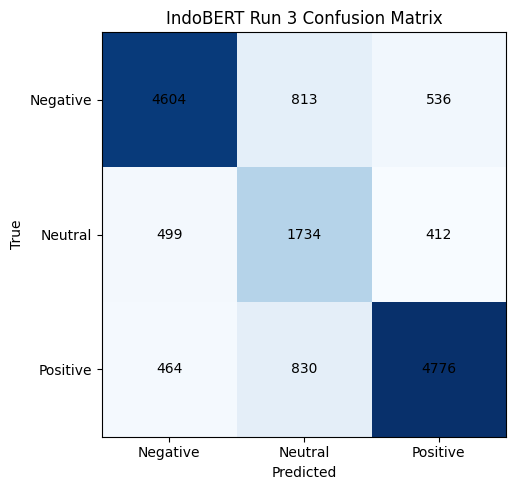

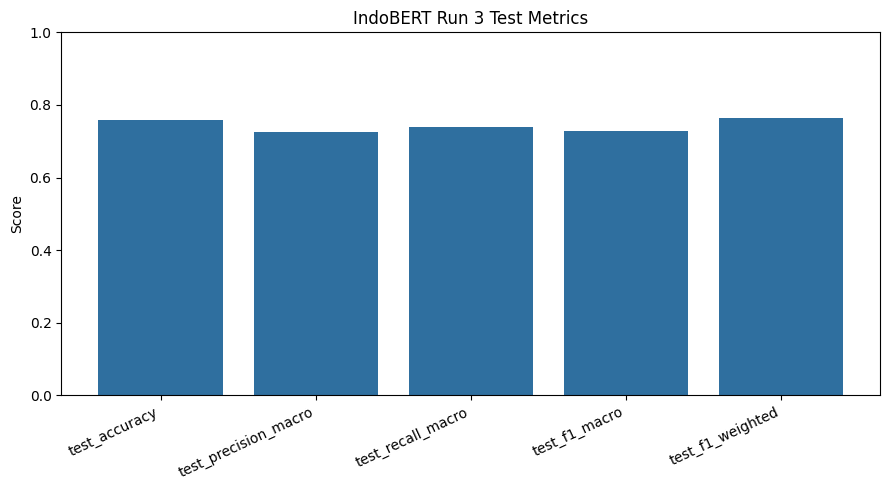

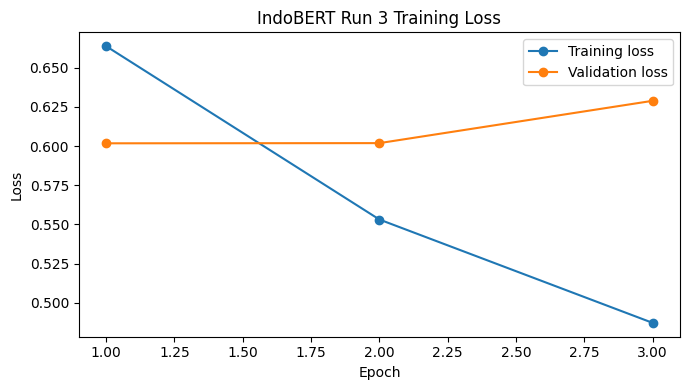

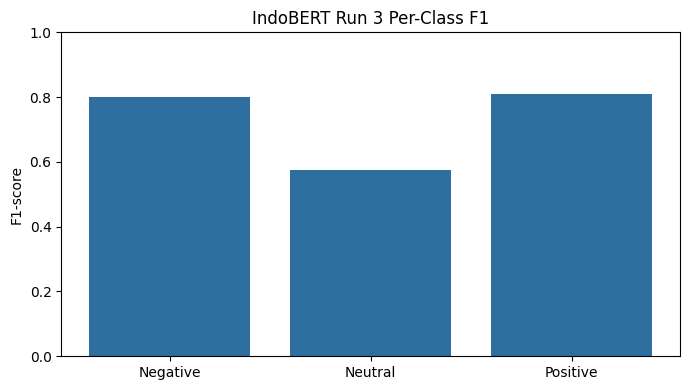

In [22]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))
plt.imshow(confusion_matrix_data, cmap="Blues")
plt.title("IndoBERT Run 3 Confusion Matrix")
plt.xticks([0, 1, 2], [id2label[0], id2label[1], id2label[2]])
plt.yticks([0, 1, 2], [id2label[0], id2label[1], id2label[2]])
plt.xlabel("Predicted")
plt.ylabel("True")
for row_index in range(confusion_matrix_data.shape[0]):
    for column_index in range(confusion_matrix_data.shape[1]):
        plt.text(column_index, row_index, confusion_matrix_data[row_index, column_index], ha="center", va="center")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_confusion_matrix.png", dpi=160)
plt.show()

metric_names = ["test_accuracy", "test_precision_macro", "test_recall_macro", "test_f1_macro", "test_f1_weighted"]
metric_values = [float(test_metrics.get(name, 0.0)) for name in metric_names]
plt.figure(figsize=(9, 5))
plt.bar(metric_names, metric_values, color="#2f6f9f")
plt.title("IndoBERT Run 3 Test Metrics")
plt.ylabel("Score")
plt.ylim(0, 1)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_eval_metrics.png", dpi=160)
plt.show()

loss_points = [(entry.get("epoch"), entry.get("loss")) for entry in trainer.state.log_history if "loss" in entry]
eval_loss_points = [(entry.get("epoch"), entry.get("eval_loss")) for entry in trainer.state.log_history if "eval_loss" in entry]
plt.figure(figsize=(7, 4))
if loss_points:
    epochs, losses = zip(*loss_points)
    plt.plot(epochs, losses, marker="o", label="Training loss")
if eval_loss_points:
    epochs, losses = zip(*eval_loss_points)
    plt.plot(epochs, losses, marker="o", label="Validation loss")
plt.title("IndoBERT Run 3 Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_training_loss.png", dpi=160)
plt.show()

class_names = [id2label[0], id2label[1], id2label[2]]
class_f1_scores = [classification_report_dict[class_name]["f1-score"] for class_name in class_names]
plt.figure(figsize=(7, 4))
plt.bar(class_names, class_f1_scores, color="#2f6f9f")
plt.title("IndoBERT Run 3 Per-Class F1")
plt.ylabel("F1-score")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURE_DIR / "indobert_class_f1_score.png", dpi=160)
plt.show()


## Multi-run Comparison Section
Load Run 1 and Run 2 outputs if available. Compare Run 1, Run 2, and Run 3 on accuracy, macro F1, weighted F1, Negative F1, Neutral precision, Neutral recall, Neutral F1, and Positive F1. Skip safely if prior run files are missing.

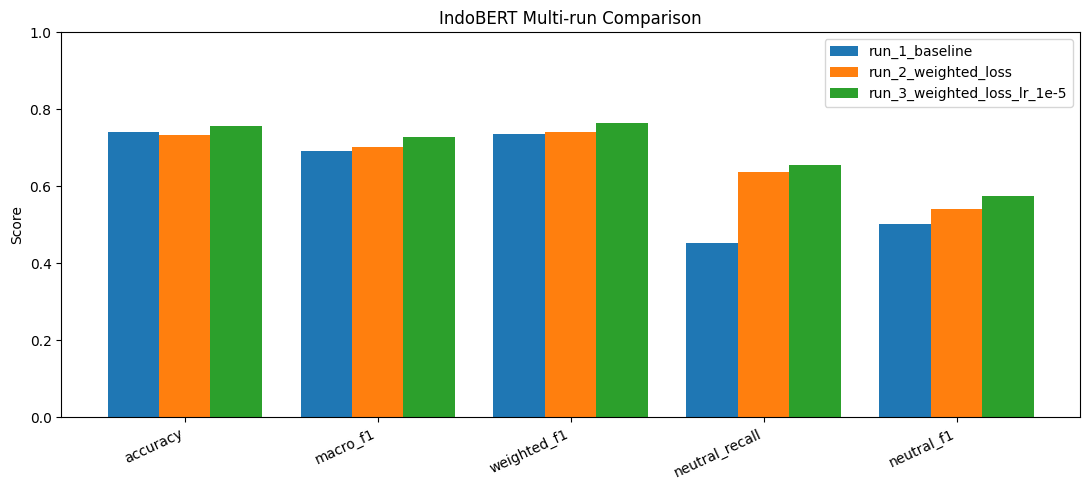

In [23]:
def load_run_summary(run_name: str, output_dir: Path):
    metrics_file = output_dir / "indobert_training_metrics.json"
    report_file = output_dir / "indobert_classification_report.json"
    if not metrics_file.is_file() or not report_file.is_file():
        print(f"Skipping {run_name}: missing metrics or classification report.")
        return None
    metrics = json.loads(metrics_file.read_text(encoding="utf-8"))
    report = json.loads(report_file.read_text(encoding="utf-8"))
    test_metrics_data = metrics.get("test_metrics", {})
    return {
        "run_name": run_name,
        "accuracy": test_metrics_data.get("test_accuracy", test_metrics_data.get("accuracy")),
        "macro_f1": test_metrics_data.get("test_f1_macro", test_metrics_data.get("f1_macro")),
        "weighted_f1": test_metrics_data.get("test_f1_weighted", test_metrics_data.get("f1_weighted")),
        "negative_f1": report["Negative"]["f1-score"],
        "neutral_precision": report["Neutral"]["precision"],
        "neutral_recall": report["Neutral"]["recall"],
        "neutral_f1": report["Neutral"]["f1-score"],
        "positive_f1": report["Positive"]["f1-score"],
    }

comparison_rows = []
for run_name, run_output_dir in [
    (BASELINE_RUN_NAME, BASELINE_OUTPUT_DIR),
    (RUN_2_NAME, RUN_2_OUTPUT_DIR),
]:
    row = load_run_summary(run_name, run_output_dir)
    if row is not None:
        comparison_rows.append(row)

comparison_rows.append(
    {
        "run_name": RUN_NAME,
        "accuracy": test_metrics.get("test_accuracy"),
        "macro_f1": test_metrics.get("test_f1_macro"),
        "weighted_f1": test_metrics.get("test_f1_weighted"),
        "negative_f1": classification_report_dict["Negative"]["f1-score"],
        "neutral_precision": classification_report_dict["Neutral"]["precision"],
        "neutral_recall": classification_report_dict["Neutral"]["recall"],
        "neutral_f1": classification_report_dict["Neutral"]["f1-score"],
        "positive_f1": classification_report_dict["Positive"]["f1-score"],
    }
)

if len(comparison_rows) >= 2:
    comparison_df = pd.DataFrame(comparison_rows)
    comparison_df.to_csv(OUTPUT_DIR / "indobert_run_comparison.csv", index=False)
    (OUTPUT_DIR / "indobert_run_comparison.json").write_text(
        comparison_df.to_json(orient="records", indent=2), encoding="utf-8"
    )
    plot_metrics = ["accuracy", "macro_f1", "weighted_f1", "neutral_recall", "neutral_f1"]
    x_positions = np.arange(len(plot_metrics))
    width = 0.8 / len(comparison_df)
    plt.figure(figsize=(11, 5))
    for row_index, (_, row) in enumerate(comparison_df.iterrows()):
        offset = (row_index - (len(comparison_df) - 1) / 2) * width
        plt.bar(x_positions + offset, row[plot_metrics], width=width, label=row["run_name"])
    plt.title("IndoBERT Multi-run Comparison")
    plt.ylabel("Score")
    plt.ylim(0, 1)
    plt.xticks(x_positions, plot_metrics, rotation=25, ha="right")
    plt.legend()
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "indobert_run_comparison.png", dpi=160)
    plt.show()
    comparison_df
else:
    print("Prior run files were not available; multi-run comparison skipped.")


## Decision Rule Section
Select the final IndoBERT candidate based on: highest macro F1, improved Neutral F1 and Neutral recall, accuracy not dropping too far, stable Negative and Positive F1, and no severe overfitting based on validation history.

## Interpretation Section
After training, document whether Run 3 improved macro F1, whether it improved the Neutral precision/recall trade-off, whether it reduced overfitting signs, whether it should replace Run 2 as the candidate final model, and what limitations remain.

## Artifact Load Verification
Verify that the exported Hugging Face artifact can be loaded from `MODEL_OUTPUT_DIR` before downloading or uploading it.


In [24]:
from transformers import AutoModelForSequenceClassification, AutoTokenizer

loaded_tokenizer = AutoTokenizer.from_pretrained(MODEL_OUTPUT_DIR)
loaded_model = AutoModelForSequenceClassification.from_pretrained(MODEL_OUTPUT_DIR)
loaded_model.eval()

sample_text = "aplikasi spotify sering error dan banyak iklan"
encoded_sample = loaded_tokenizer(sample_text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
with torch.no_grad():
    sample_output = loaded_model(**encoded_sample)

sample_probs = torch.softmax(sample_output.logits, dim=-1)[0]
sample_label_id = int(torch.argmax(sample_probs).item())
print({
    "loaded": True,
    "sample_label": loaded_model.config.id2label[sample_label_id],
    "confidence": float(sample_probs[sample_label_id]),
})


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

{'loaded': True, 'sample_label': 'Negative', 'confidence': 0.8900814056396484}


## Zip Artifact for Download
Zip only the exported model artifact folder. Do not include checkpoints or raw datasets in the archive.


In [25]:
import shutil

zip_base = OUTPUT_DIR / RUN_NAME
zip_path = shutil.make_archive(str(zip_base), "zip", root_dir=MODEL_OUTPUT_DIR)
print("Artifact zip:", zip_path)


Artifact zip: /content/drive/MyDrive/SentiRank/outputs/indobert/run_3_weighted_loss_lr_1e-5/run_3_weighted_loss_lr_1e-5.zip


## Optional Hugging Face Hub Upload
Default behavior is no upload. For thesis-stage work, use a private repository. Do not paste tokens into notebook cells; set `HF_TOKEN` through Colab secrets or an environment variable.


In [26]:
import os
from getpass import getpass

os.environ["HF_TOKEN"] = getpass("Masukkan Hugging Face token: ")

Masukkan Hugging Face token: ··········


In [27]:
from huggingface_hub import HfApi
import os

PUSH_TO_HUB = True
HF_REPO_ID = "ahmadzkh/sentirank-indobert-run3"
HF_PRIVATE = True
HF_TOKEN_ENV = "HF_TOKEN"

hf_token = os.environ.get(HF_TOKEN_ENV)
if not hf_token:
    raise RuntimeError(f"PUSH_TO_HUB=True but {HF_TOKEN_ENV} is not set.")

api = HfApi()
api.create_repo(
    repo_id=HF_REPO_ID,
    private=HF_PRIVATE,
    exist_ok=True,
    token=hf_token,
)

api.upload_folder(
    folder_path=str(MODEL_OUTPUT_DIR),
    repo_id=HF_REPO_ID,
    token=hf_token,
    commit_message=f"Upload SentiRank IndoBERT artifact {RUN_NAME}",
)

print({"uploaded": True, "repo_id": HF_REPO_ID, "private": HF_PRIVATE})

/usr/local/lib/python3.12/dist-packages/huggingface_hub/hf_api.py:11299: UserWarning: Warnings while validating metadata in README.md:
- empty or missing yaml metadata in repo card
  warnings.warn(f"Warnings while validating metadata in README.md:\n{message}")


{'uploaded': True, 'repo_id': 'ahmadzkh/sentirank-indobert-run3', 'private': True}


## Local Repository Sync Note
Copy small Run 3 metrics to `datasets/outputs/eda/03_indobert/run_3_weighted_loss_lr_1e-5/` and figures to `docs/figures/03_indobert/run_3_weighted_loss_lr_1e-5/`. Do not commit `saved_model/`, checkpoints, `model.safetensors`, `pytorch_model.bin`, or large prediction files if they are too large for the repository policy.

## Next Step
Compare Run 1, Run 2, and Run 3. If Run 3 improves macro F1 or gives a better Neutral trade-off, use Run 3 as the candidate final model. If Run 3 does not improve, keep Run 2 as the candidate final model. Then proceed to final IndoBERT evaluation documentation.